# Set-up

## Load libraires

In [4]:
setwd("C:/Users/atanoh/Documents/2025/stage/C03_Torres_2005/CAP")
#Install and load libraires
source("./src/libraries.r")
# Functions
invisible(lapply(list.files("./src/descriptive_stats", full.names = TRUE), source))
invisible(lapply(list.files("./src/models", full.names = TRUE), source))

Warning message in .checkFieldsInMethod(def, fieldNames, allMethods):
"affectation non-locale à des noms qui ne sont pas des champs (coquille possible ?)
    imp <<- dataset
(dans la méthode "initialize" de la classe "logit")"
Warning message in .checkFieldsInMethod(def, fieldNames, allMethods):
"affectation non-locale à des noms qui ne sont pas des champs (coquille possible ?)
    imp_data <<- dataset; time_event_pairs <<- time_event_pairs
(dans la méthode "initialize" de la classe "cox")"


## Load dataset

In [5]:
data <- read_sav("./Torres_bd_vf.sav")
data <- data %>%
  mutate(across(where(~ inherits(.x, "haven_labelled")), ~ as.factor(.x)))

# Data exploration

## Load and treat dataset

In [7]:
#Characteristics of dataset
torres_caracs=characteristics(data[, !sapply(data, inherits, what = "Date")])
#Correction
data[["daysinICU"]]=as.numeric(data$EvolUCIFechaAlta-data$EvolUCIFechaIngr)+1
check_dias_uci <- with(data, 
  ((is.na(EvolDiasUCI)| EvolDiasUCI==0) & is.na(EvolUCIFechaAlta) & is.na(EvolUCIFechaIngr)) |
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr)+1)|
  (!is.na(EvolDiasUCI) & EvolDiasUCI == as.numeric(EvolUCIFechaAlta - EvolUCIFechaIngr))
)
# EvolDiasUCI vs EvolIUCI 
check_iuci <- with(data,
  EvolUCI == 0 | !is.na(EvolDiasUCI)
)
invalid <- which(!check_dias_uci %in% TRUE)  # selects only FALSE (excludes NA)
data$EvolDiasUCI[invalid] <- data$daysinICU[invalid]
data[!check_dias_uci,c("EvolDiasUCI","daysinICU","EvolUCIFechaIngr","EvolUCIFechaAlta")]
#Create variables
#Year of admission
data$YearOfAdmission <- as.factor(format(as.Date(data$FechaIngr), "%Y"))
#Ratio Pao2/FiO2
data$RatioPao2_oxygen <- data$GpO201/(data$GFiO201/100)
#Macrolide therapy
abx_vars <- paste0("TAntibiotico", 1:12)
macrolides <- c("azitromicina", "claritromicina", "eritromicina")
data$macrolide <- factor(
  apply(data[abx_vars], 1, function(row) any(row %in% macrolides, na.rm = TRUE)),
  levels = c(FALSE, TRUE),
  labels = c(0, 1)
)
data <- data %>%
  mutate(TimeToFirstAntibiotic_SS = case_when(
    TTiempoDesdeLlegUCIAS <= 1 & CdxShockSept == 1 ~ "0",
    TTiempoDesdeLlegUCIAS <= 4 & CdxShockSept == 0 ~ "1",
    TRUE ~ NA_character_  # For all other cases
  )) %>%
  mutate(TimeToFirstAntibiotic_SS = as.factor(TimeToFirstAntibiotic_SS))
  #Oder by patient ids
data <- data[order(data$IdPac), ]

#Select variables of interest
vars_dint <- c("IdPac","YearOfAdmission","Edad",
"Sexo",
"Fumador",
"Diabetes",
"EPOC",
"HTA",
"Cancer",
"CardIsq",
"CFiebre",
"CAlterNivelConc",
"CDisnea",
"CTos",
"CEscalofrios",
"CDolorPleur",
"FINE",
"Puntos",
"CdxVM",
"CdxVMtipo",
"CdxShockSept",
"CdxPAP90",
"CdxMultilobar",
"CdxPaFi250",
"RatioPao2_oxygen",
"UCI_Interm",
"TimeToFirstAntibiotic_SS",
"macrolide",
"BGlucosa",
"BCreatinina",
"HPlaquetas",
"HLeucocitos",
"BProteinasTot",
"PCT1",
"IL61",
"IL81",
"IL101",
"Temperatura",
"FR",
"FC",
"EarlyFailure",
"EMV",
"ESS",
"ED",
"LateFailure",
"RP",
"RF",
"LMV",
"LSS",
"tiempo_estancia",
"EvolDiasUCI",
"EvolMort28",
"EstabClin",
"Dia_TF",
"Grupo",
"ITT",
"PP",
"Centro"
)


EvolDiasUCI,daysinICU,EvolUCIFechaIngr,EvolUCIFechaAlta
<dbl>,<dbl>,<date>,<date>
11,11,2004-09-10,2004-09-20
5,5,2004-12-07,2004-12-11
35,35,2005-03-15,2005-04-18
NA,NA,NA,NA
16,16,2006-03-28,2006-04-12
63,63,2006-04-20,2006-06-21
9,9,2006-12-28,2007-01-05
10,10,2007-03-07,2007-03-16
10,10,2007-10-23,2007-11-01


In [10]:
#Convert data type
data_dint<-data[,vars_dint] %>%
  mutate(FINE=as.factor(FINE))%>%
  mutate(BProteinasTot =as.numeric(as.character(BProteinasTot)))%>%
  mutate(PCT1 =as.numeric(as.character(PCT1 )))%>%
  mutate(IL61 =as.numeric(as.character(IL61 )))%>%
  mutate(IL81 =as.numeric(as.character(IL81 )))%>%
  mutate(IL101 =as.numeric(as.character(IL101)))
data_dint[["ratio_il6_il10"]]=data_dint$IL101/data_dint$IL61
#Manually builds early and late failure
data_dint$EarlyFailureMan <- with(data_dint, factor(as.integer(EMV == 1 | ESS == 1 | ED == 1), levels = c(0,1)))
data_dint$LateFailureMan <- with(data_dint, factor(as.integer(LMV == 1 | LSS == 1 | RP == 1 | RF == 1), levels = c(0,1)))
data_dint$TreatmentFailureMan <- with(data_dint, factor(as.integer(EarlyFailureMan == 1 | LateFailureMan == 1), levels = c(0,1)))
# #Suppress
#data_dint <- data_dint %>% select(-TreatmentFailure, -LateFailure, -EarlyFailure)
#Compute pleural effusion
data$pleural_effusion <- with(data, factor(as.integer(!is.na(LPGlu) | !is.na(LPProt)| !is.na(LPLDH)| 
!is.na(LPCelulas)| !is.na(LPPM)), levels = c(0,1))) 
# table(data$Cancer,data$Grupo) 
caracs_dint<-characteristics(data_dint)
caracs_dint

variable,types,nombre_de_modalites,number_of_missing_values,proportion_missing_values_percent,moyenne,maximum,minimum,mode,proportion_mode_percent
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
IdPac,numeric,95,0,0.0,47.633333,301.0000,1.0,20,1.667
YearOfAdmission,factor,9,0,0.0,NA,NA,NA,2,0.000
Edad,numeric,59,0,0.0,65.241667,96.0000,19.0,81,7.500
Sexo,factor,2,0,0.0,NA,NA,NA,2,0.000
Fumador,factor,3,0,0.0,NA,NA,NA,3,0.000
Diabetes,factor,2,0,0.0,NA,NA,NA,1,19.167
EPOC,factor,2,0,0.0,NA,NA,NA,1,15.833
HTA,factor,2,0,0.0,NA,NA,NA,1,38.333
Cancer,factor,2,0,0.0,NA,NA,NA,1,9.167


Missing informations for temperature, respiratory and heart rates mostly

,IdPac,YearOfAdmission,Edad,Sexo,Fumador,Diabetes,EPOC,HTA,Cancer,CardIsq,⋯,IL81,EstabClin,EvolDiasUCI,FC,FR,Temperatura,TimeToFirstAntibiotic_SS,BProteinasTot,Dia_TF,
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,1,0
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,1,0,1
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,1,1
20,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,1,0,0,2
4,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,1,0,2
3,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,1,2
14,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,1,0,0,0,3
1,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,1,1,0,1,0,0,3
2,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,1,0,1,4
5,1,1,1,1,1,1,1,1,1,1,⋯,1,1,1,0,0,0,0,0,0,6


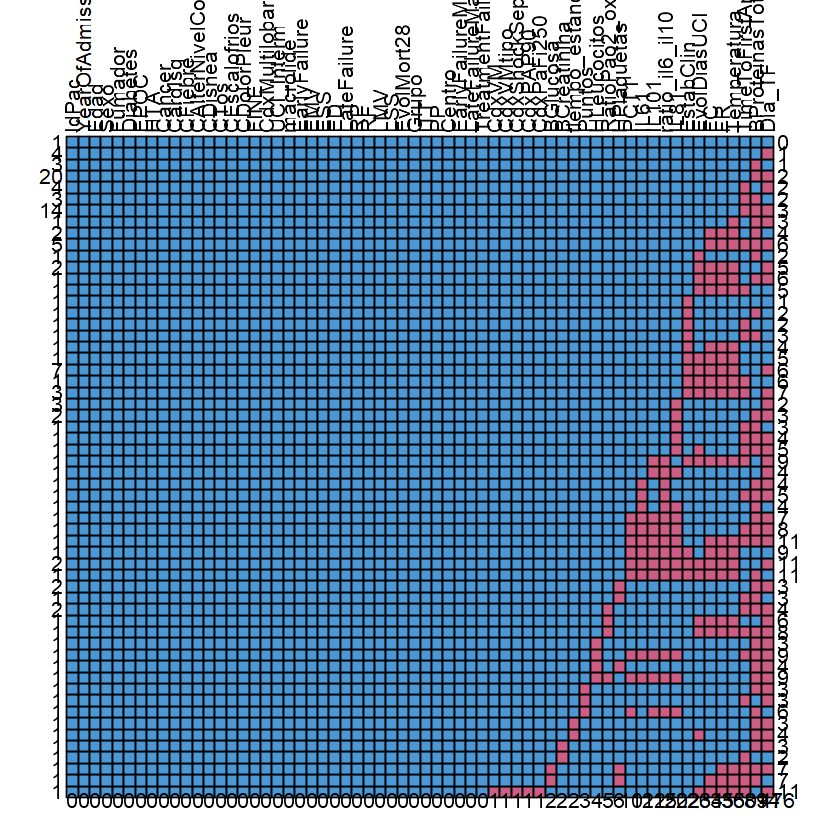

In [11]:
md.pattern(data_dint, rotate.names = TRUE)

Let's suppose MAR

## Intention to treat

### Descriptive statistics

In [12]:
#Test normality of numerical variables
normality <- sapply(data_dint[!names(data_dint) %in% "IdPac"],seek_normality)
data.frame(variable = names(normality), normality = normality)

,variable,normality
,<chr>,<chr>
YearOfAdmission,YearOfAdmission,NA
Edad,Edad,not normal
Sexo,Sexo,NA
Fumador,Fumador,NA
Diabetes,Diabetes,NA
EPOC,EPOC,NA
HTA,HTA,NA
Cancer,Cancer,NA
CardIsq,CardIsq,NA


In [14]:
#Explicit modalities of categorical variables
data_dint_explcit<-data_dint %>%
  mutate(Sexo = recode(Sexo, "1" = "Male", "0" = "Female")) %>%
  mutate(Diabetes = recode(Diabetes, "1" = "Diabetes mellitus", "0" = "Not diabetic"))%>%
  mutate(Fumador = recode(Fumador, "1" = "Current smoker", "0" = "Not smoker"))%>%
  mutate(EPOC = recode(EPOC, "1" = "Chronic pulmonary disease", "0" = "Not EPOC"))%>%
  mutate(HTA = recode(HTA, "1" = "Congestive heart failure", "0" = "Not HTA"))%>%
  mutate(Cancer = recode(Cancer, "1" = "History of malignancy", "0" = "No cancer"))%>%
  mutate(CardIsq = recode(CardIsq, "1" = "Ischemic heart disease", "0" = "No IHD"))%>%
  mutate(CFiebre = recode(CFiebre, "1" = "Fever", "0" = "No fever"))%>%
  mutate(CAlterNivelConc = recode(CAlterNivelConc, "1" = "Altered Mental status", "0" = "Not altered"))%>%
  mutate(CDisnea = recode(CDisnea, "1" = "Breathlessness", "0" = "No Breathlessness"))%>%
  mutate(CTos = recode(CTos, "1" = "Cough", "0" = "No cough"))%>%
  mutate(CEscalofrios = recode(CEscalofrios, "1" = "Chills", "0" = "No chills"))%>%
  mutate(CDolorPleur = recode(CDolorPleur, "1" = "Chest pain", "0" = "No chest pain"))%>%
  mutate(CdxVM = recode(CdxVM, "1" = "Mechanical ventialtion", "0" = "No MV"))%>%
  mutate(CdxVMtipo = recode(CdxVMtipo, "1" = "Noninvasive alone","2" = "Noninvasive followed by invasive","3" = "Invasive alone", "0" = "No MV"))%>%
  mutate(CdxShockSept = recode(CdxShockSept, "1" = "Septic shock", "0" = "No shock"))%>%
  mutate(CdxPAP90 = recode(CdxPAP90, "1" = "Systolic blood pressure< 90 mmHg", "0" = "PAP>90"))%>%
  mutate(CdxMultilobar = recode(CdxMultilobar, "1" = "Multilobar involvement", "0" = "No involvement"))%>%
  mutate(CdxPaFi250 = recode(CdxPaFi250, "1" = "Ratio of PaO2 to fraction of inspired oxygen < 250 mmHg", "0" = "Ratio>250"))%>%
  mutate(UCI_Interm = recode(UCI_Interm, "1" = "ICU admission", "0" = "No ICU admission"))%>%
  mutate(TimeToFirstAntibiotic_SS = recode(TimeToFirstAntibiotic_SS, "1" = "Within 1h in patients with septic shock", "0" = "Within 4h in patients without septic shock"))%>% 
  mutate(macrolide = recode(macrolide, "1" = " Macrolide combination therapy", "0" = "No macrolide"))%>%
  mutate(EarlyFailureMan = recode(EarlyFailureMan, "1" = "Early failure", "0" = "No early failure"))%>%
  mutate(EMV = recode(EMV, "1" = "Early mechanical ventilation", "0" = "EVM"))%>%
  mutate(ESS = recode(ESS, "1" = "Early septic shock", "0" = "no ESS"))%>%
  mutate(ED = recode(ED, "1" = "Early death", "0" = "no ED"))%>%
  mutate(LateFailureMan = recode(LateFailureMan, "1" = "Late failure", "0" = "No late failure"))%>%
  mutate(RP = recode(RP, "1" = "Radiographic progression", "0" = "no RP"))%>%
  mutate(RF = recode(RF, "1" = "Respiratory failure", "0" = "no RF"))%>%
  mutate(LMV = recode(LMV, "1" = "Late mechanical ventilation", "0" = "no LMV"))%>%
  mutate(LSS = recode(LSS, "1" = "Late septic shock", "0" = "no LSS"))%>%
  mutate(EvolMort28 = recode(EvolMort28, "1" = "In-hospitality mortality", "0" = "no IHM"))%>%
  mutate(TreatmentFailureMan = recode(TreatmentFailureMan, "1" = "Treatment failure", "0" = "No treatment failure"))
#Summary of categorical variables
summary_cat_by_group(data_dint_explcit, "Grupo")

Variable,Category,Overall_N_prop,0_N_prop,1_N_prop
<chr>,<chr>,<chr>,<chr>,<chr>
YearOfAdmission,2004,8 (6.7%),5 (8.5%),3 (4.9%)
YearOfAdmission,2005,24 (20%),13 (22%),11 (18%)
YearOfAdmission,2006,21 (17.5%),8 (13.6%),13 (21.3%)
YearOfAdmission,2007,17 (14.2%),7 (11.9%),10 (16.4%)
YearOfAdmission,2008,14 (11.7%),7 (11.9%),7 (11.5%)
YearOfAdmission,2009,9 (7.5%),6 (10.2%),3 (4.9%)
YearOfAdmission,2010,13 (10.8%),7 (11.9%),6 (9.8%)
YearOfAdmission,2011,12 (10%),5 (8.5%),7 (11.5%)
YearOfAdmission,2012,2 (1.7%),1 (1.7%),1 (1.6%)


In [15]:
# Summary of numerical variables 
summary_num_by_group(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Variable,Overall_mean_SD,Overall_med_IQR,Overall_min_max,0_mean_SD,0_med_IQR,0_min_max,1_mean_SD,1_med_IQR,1_min_max
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Edad,65.2 (19.6),69.5 (53.0 - 81.0),19.0 - 96.0,66.1 (20.1),70.0 (54.5 - 81.0),19.0 - 96.0,64.5 (19.1),69.0 (53.0 - 81.0),24.0 - 89.0
Puntos,108.6 (36.4),110.0 (86.0 - 135.0),4.0 - 212.0,110.2 (34.6),111.0 (91.0 - 135.0),4.0 - 173.0,107.1 (38.2),109.0 (85.8 - 134.2),28.0 - 212.0
RatioPao2_oxygen,232.9 (78.7),238.1 (179.6 - 270.5),63.6 - 609.5,229.6 (82.9),228.6 (170.5 - 287.6),76.0 - 407.5,236.2 (74.9),239.0 (210.1 - 265.6),63.6 - 609.5
BGlucosa,149.5 (72.4),130.5 (106.0 - 167.2),50.0 - 548.0,150.8 (65.6),129.0 (107.0 - 180.0),50.0 - 394.8,148.3 (78.9),131.0 (106.0 - 159.0),64.0 - 548.0
BCreatinina,1.6 (0.9),1.3 (1.0 - 1.8),0.4 - 5.2,1.6 (1.0),1.3 (1.0 - 1.8),0.4 - 5.2,1.5 (0.9),1.3 (0.9 - 1.8),0.6 - 4.9
HPlaquetas,248.0 (131.7),214.5 (175.2 - 283.0),32.0 - 864.0,260.4 (150.8),217.0 (175.0 - 283.0),81.0 - 864.0,235.7 (109.3),214.0 (176.0 - 282.0),32.0 - 630.0
HLeucocitos,15.1 (10.7),13.4 (9.0 - 19.7),0.7 - 74.0,14.9 (9.0),14.4 (9.2 - 23.0),0.7 - 36.7,15.3 (12.2),12.6 (9.0 - 16.7),1.3 - 74.0
BProteinasTot,27.8 (24.8),8.2 (6.6 - 56.5),4.9 - 69.0,23.4 (23.0),7.5 (6.8 - 47.0),5.2 - 58.0,31.2 (26.1),19.6 (6.3 - 57.5),4.9 - 69.0
PCT1,6.3 (11.8),1.8 (0.5 - 7.2),0.0 - 86.3,6.7 (8.6),3.1 (0.8 - 9.5),0.1 - 37.4,6.0 (14.2),1.2 (0.4 - 4.4),0.0 - 86.3


### Comparison tests

In [16]:
compare_var_cat(data_dint[!names(data_dint) %in% "IdPac"],"Grupo")

Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingency):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in chisq.test(contingenc

Variable,Test,P_value,Verdict
<chr>,<chr>,<dbl>,<chr>
YearOfAdmission,Fisher,0.886,No significative difference
Sexo,Chi2,0.427,No significative difference
Fumador,Chi2,0.872,No significative difference
Diabetes,Chi2,0.580,No significative difference
EPOC,Chi2,0.280,No significative difference
HTA,Chi2,0.740,No significative difference
Cancer,Chi2,0.186,No significative difference
CardIsq,Chi2,0.692,No significative difference
CFiebre,Chi2,0.346,No significative difference


In [17]:
#Double check for septic shock
contingency <- table(data_dint$CdxShockSept, data_dint$Grupo)
print(chisq.test(contingency)$p.value)
print(fisher.test(contingency)$p.value)
# if (pval < 0.1) "associated/significative difference" else "No significative difference"

[1] 0.1178949
[1] 0.08699988


Associated/significatve difference for the the fisher test

In [18]:
compare_var_num(data_dint[!names(data_dint) %in% "IdPac"], "Grupo")

Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"
Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"impossible de calculer la p-value exacte avec des ex-aequos"


Variable,test,pvalue,verdict
<chr>,<chr>,<dbl>,<chr>
Edad,Mann-Whitney,0.592,No significative difference
Puntos,Student,0.652,No significative difference
RatioPao2_oxygen,Mann-Whitney,0.695,No significative difference
BGlucosa,Mann-Whitney,0.620,No significative difference
BCreatinina,Mann-Whitney,0.607,No significative difference
HPlaquetas,Mann-Whitney,0.792,No significative difference
HLeucocitos,Mann-Whitney,0.485,No significative difference
BProteinasTot,Mann-Whitney,0.542,No significative difference
PCT1,Mann-Whitney,0.040,associated/significative difference


In [19]:
#Compare proportions
compare_proportions(data_dint[!names(data_dint) %in% "IdPac"], c("TreatmentFailureMan"
                                ,"EarlyFailureMan","EMV","ESS","ED",
                                "LateFailureMan","RP","RF","LMV","LSS"),
                                 "Grupo")

Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"
Warning message in prop.test(successes, totals, correct = FALSE):
"L’approximation du Chi-2 est peut-être incorrecte"


Variable,P_value,Difference_CI
<chr>,<dbl>,<chr>
TreatmentFailureMan,0.02,17 (3–31)
EarlyFailureMan,0.95,0 (-10–11)
EMV,0.69,2 (-8–11)
ESS,0.62,2 (-5–9)
ED,0.97,0 (-6–7)
LateFailureMan,0.00,22 (11–33)
RP,0.01,14 (4–23)
RF,0.09,7 (-1–15)
LMV,0.16,5 (-2–12)


In [20]:
compare_medians(data_dint[!names(data_dint) %in% "IdPac"], c("tiempo_estancia","EstabClin"),"Grupo")

Variable,Median_Diff,CI_95,P_value
<chr>,<dbl>,<chr>,<dbl>
tiempo_estancia,0.5,-2.51 – 3,0.8311
EstabClin,-1.0,-2 – 1,0.2769


In [ ]:
group0 <- data_dint[data_dint[["Grupo"]] == 0 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
group1 <- data_dint[data_dint[["Grupo"]] == 1 & data_dint$EvolDiasUCI>0, "EvolDiasUCI", drop = TRUE]
    
    # Remove NA
group0 <- group0[!is.na(group0)]
group1 <- group1[!is.na(group1)]
if (length(group0) == 0 || length(group1) == 0) return(NULL)

    # Median difference
diff_median <- round(median(group1) - median(group0), 2)
    
    # P-value
p_val <- round(wilcox.test(group0, group1, exact = FALSE)$p.value, 4)
    
    # Bootstrap CI for median difference
boot_diffs <- replicate(1000, {
      med1 <- median(sample(group1, replace = TRUE))
      med0 <- median(sample(group0, replace = TRUE))
      med1 - med0
    })
    
ci <- quantile(boot_diffs, probs = c((1 - 0.95)/2, 1 - (1 - 0.95)/2))
ci_str <- paste0(round(ci[1], 2), " – ", round(ci[2], 2))
    
data.frame(
      Variable = "EvolDiasUCI",
      Median_Diff = diff_median,
      CI_95 = ci_str,
      P_value = p_val,
      stringsAsFactors = FALSE
    )

Significative difference for procalcitonin, IL-10 and septic shock

### Impute missing values

In [ ]:
#Imputation
vars_to_impute<-caracs_dint[caracs_dint$number_of_missing_values>0,"variable"]
print(caracs_dint[caracs_dint$number_of_missing_values>0,"variable"])

In [ ]:
# List of all column names
all_vars <- names(data_dint[!names(data_dint) %in% "IdPac"])

# Create a method vector with empty strings
meth <- rep("", length(all_vars))
names(meth) <- all_vars

# Set "pmm" only for the 3 target columns
meth[c("PCT1", "IL101","CdxShockSept")] <- "pmm"

# Run mice with the method vector
imp <- mice(data_dint[!names(data_dint) %in% "IdPac"], m = 5, method = meth, seed = 123)

### Logistic regression